In [1]:
# ─── GCP / Colab Enterprise setup (skip on local) ───────────────────────────
# This cell is a no-op when running locally (detected via /home/ennes path).
# On GCP, it downloads the code archive from GCS, unpacks it, and pip-installs
# all dependencies.
import os, sys, subprocess

_ON_GCP = not os.path.exists("/home/ennes")

if _ON_GCP:
    # ── 1. Download and unpack archive from GCS ──────────────────────────────
    GCS_ARCHIVE = "gs://ennes_mestrado/mmm/mmm_experiment_20260404.tar.gz"
    UNPACK_DIR  = "/content"

    subprocess.run(["gcloud", "storage", "cp", GCS_ARCHIVE, "/tmp/mmm.tar.gz"], check=True)
    subprocess.run(["tar", "-xzf", "/tmp/mmm.tar.gz", "-C", UNPACK_DIR], check=True)
    print(f"Unpacked to {UNPACK_DIR}/")

    PYMC_COMPARISON_ROOT = f"{UNPACK_DIR}/pymc_meridian_comparison"
    CAUSALMMM_ROOT       = f"{UNPACK_DIR}/causalmmm_with_cdnots"

    # ── 2. Install packages (pinned to match local pixi env) ─────────────────
    pkgs = [
        "pymc==5.24.1",
        "pymc-marketing==0.15.1",
        "arviz==0.20.0",
        "pytensor==2.31.7",
        "blackjax==1.3",
        "nutpie==0.16.6",
        "numpyro==0.20.1",
        "numpy==2.4.3",
        "pandas==2.3.3",
        "xarray==2026.2.0",
        "statsmodels==0.14.6",
        "tensorflow==2.18.0",
        "tensorflow-probability==0.25.0",
        "google-meridian==1.4.0",
        "causal-learn",
        "networkx==3.6.1",
        "rich==14.3.3",
        "great-tables==0.18.0",
    ]
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet"] + pkgs,
        check=True
    )

    # ── 3. Install local packages ─────────────────────────────────────────────
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "-e", PYMC_COMPARISON_ROOT],
        check=True
    )

    # Expose paths for the rest of the notebook
    os.environ["PYMC_COMPARISON_ROOT"] = PYMC_COMPARISON_ROOT
    os.environ["CAUSALMMM_ROOT"]       = CAUSALMMM_ROOT

    print("GCP setup complete.")
else:
    print("Local environment detected — skipping GCP setup.")


Local environment detected — skipping GCP setup.


# Experimento de 4 Braços: CD-NOTS + MMM Bayesiano

**Investigação da Utilização de Descoberta de Estruturas Causais para Calibração de Modelos Bayesianos em Marketing Mix Modeling**

Rafael Silva Ennes — Universidade Presbiteriana Mackenzie, 2026

---

## Design Experimental

| Braço | Descoberta Causal | Framework | Priors |
|-------|-------------------|-----------|--------|
| 1 | Nenhuma | PyMC-Marketing | Padrão (spend-share) |
| 2 | Nenhuma | Google Meridian | Padrão (spend-share) |
| 3 | CD-NOTS | PyMC-Marketing | Calibrados pelo grafo |
| 4 | CD-NOTS | Google Meridian | Calibrados pelo grafo |

A comparação Braço 1 vs 3 e Braço 2 vs 4 isola o efeito da descoberta causal mantendo o framework constante.

---

## Pipeline

```
Dados sintéticos (ground truth conhecido)
         ↓
[Fase 0] CD-NOTS → Grafo causal (direto / mediado / excluído)
         ↓
[Fase 1] Fitting dos 4 braços (2 baseline + 2 graph-informed)
         ↓
[Fase 2] Avaliação: métricas preditivas, atribuição, estrutura, MCMC
```

---
## Seção 0: Configuração do Ambiente

In [2]:
# ─── Monkey-patch: TFP compatibility with numpy 2.x ─────────────────────────
# numpy 2.0 renamed np.reshape's 'newshape' kwarg to 'shape'.
# TFP 0.25.0 (conda-forge) still calls np.reshape(arr, newshape=...) in
# pad.py and empirical_statistical_testing.py. Patch restores it so those
# calls don't raise TypeError. Must run BEFORE any tensorflow_probability import.
import numpy as _np
if not hasattr(_np, '_tfp_newshape_patched'):
    _orig_reshape = _np.reshape
    def _reshape_compat(a, newshape=None, order='C', *, shape=None):
        s = newshape if newshape is not None else shape
        if s is None:
            raise TypeError("reshape() requires a 'shape' argument")
        return _orig_reshape(a, s, order)
    _np.reshape = _reshape_compat
    _np._tfp_newshape_patched = True
del _np
print('numpy reshape patched for TFP compatibility')


numpy reshape patched for TFP compatibility


In [3]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")

# ─── Paths das duas repos ───────────────────────────────────────────────────
PYMC_COMPARISON_ROOT = os.environ.get("PYMC_COMPARISON_ROOT", "/home/ennes/mestrado/pymc_meridian_comparison")
CAUSALMMM_ROOT       = os.environ.get("CAUSALMMM_ROOT",       "/home/ennes/mestrado/causalmmm_with_cdnots")
ARQUIVOS_RECENTES    = os.path.join(CAUSALMMM_ROOT, "arquivos_recentes")
RESULTS_BASE_DIR = os.path.join(CAUSALMMM_ROOT, "notebooks", "resultados")
os.makedirs(RESULTS_BASE_DIR, exist_ok=True)

for p in [PYMC_COMPARISON_ROOT, CAUSALMMM_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"RESULTS_BASE_DIR: {RESULTS_BASE_DIR}")
print("Paths configurados.")

RESULTS_BASE_DIR: /home/ennes/mestrado/causalmmm_with_cdnots/notebooks/resultados
Paths configurados.


In [4]:
import gc
import pickle
import time
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from rich.console import Console
from rich.table import Table

# ─── mmm_param_recovery ─────────────────────────────────────────────────────
from mmm_param_recovery.data_generator.core import generate_mmm_dataset
from mmm_param_recovery.data_generator.presets import get_preset_config
from mmm_param_recovery.benchmarking.data_loader import prepare_dataset_for_modeling
from mmm_param_recovery.benchmarking import model_builder, model_fitter, diagnostics, evaluation

# ─── causalmmm (estrutura causal) ────────────────────────────────────────────
from causalmmm.metrics.evaluation import evaluate_causal_structure

console = Console()
console.print("[green]Imports principais OK[/green]")

# ─── Módulos CD-NOTS (com fallback via importlib) ────────────────────────────
def _load_cdnots_module(name: str, filepath: str):
    """Carrega módulo CD-NOTS registrando no namespace do pacote benchmarking.
    Necessário pois os módulos usam imports relativos (from . import model_builder).
    """
    full_name = f"mmm_param_recovery.benchmarking.{name}"
    spec = importlib.util.spec_from_file_location(full_name, filepath)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[full_name] = mod
    spec.loader.exec_module(mod)
    return mod

try:
    # Tenta importar do pacote (se os arquivos já foram copiados para benchmarking/)
    from mmm_param_recovery.benchmarking import cdnots_discovery, cdnots_model_builder, cdnots_fitter
    console.print("[green]CD-NOTS: módulos carregados do pacote benchmarking[/green]")
except ImportError:
    # Fallback: carrega via importlib em ordem de dependência
    cdnots_discovery     = _load_cdnots_module("cdnots_discovery",
                               os.path.join(ARQUIVOS_RECENTES, "cdnots_discovery.py"))
    cdnots_model_builder = _load_cdnots_module("cdnots_model_builder",
                               os.path.join(ARQUIVOS_RECENTES, "cdnots_model_builder.py"))
    cdnots_fitter        = _load_cdnots_module("cdnots_fitter",
                               os.path.join(ARQUIVOS_RECENTES, "cdnots_fitter.py"))
    console.print("[yellow]CD-NOTS: módulos carregados via importlib (fallback)[/yellow]")

# ─── Meridian: disponibilidade condicional ───────────────────────────────────
try:
    from meridian.model import model as meridian_model_lib  # noqa
    MERIDIAN_AVAILABLE = True
    console.print("[green]Meridian: disponível[/green]")
except ImportError:
    MERIDIAN_AVAILABLE = False
    console.print("[yellow]Meridian: não disponível — braços 2 e 4 serão pulados[/yellow]")

2026-04-05 10:10:53.055364: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Imports principais OK

CD-NOTS: módulos carregados via importlib (fallback)

Meridian: disponível

---
## Seção 1: Geração dos Dados Sintéticos

Utilizamos o preset **`small_business`** do framework `mmm_param_recovery`:
- 1 geo ("Local")
- 4 canais de marketing
- 2 variáveis de controle
- 104 semanas (~2 anos)

O dataset tem **ground truth conhecido**: parâmetros de adstock, saturação, contribuições verdadeiras por canal e ROAS verdadeiro.

In [5]:
SEED        = 20250715
PRESET_NAME = "causal_large"

config         = get_preset_config(PRESET_NAME, seed=SEED)
dataset_result = generate_mmm_dataset(config)

data_df, channel_columns, control_columns, truth_df = prepare_dataset_for_modeling(
    dataset_result, console=console
)

# Results dir scoped to this preset — no overwrite across presets
RESULTS_DIR = os.path.join(RESULTS_BASE_DIR, PRESET_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save raw data and ground truth for reproducibility
data_df.to_csv(os.path.join(RESULTS_DIR, "data.csv"), index=True)
truth_df.to_csv(os.path.join(RESULTS_DIR, "ground_truth.csv"), index=True)

console.print(f"\nCanais: {channel_columns}")
console.print(f"Controles: {control_columns}")
console.print(f"Shape data_df: {data_df.shape}")
console.print(f"Shape truth_df: {truth_df.shape}")
console.print(f"[green]RESULTS_DIR → {RESULTS_DIR}[/green]")
data_df.head()


 Dataset shape             208 rows × 44 columns                                                
  Effective modeling size   208 rows × 33 columns (time, geo, 20 channels, 10 controls, target)  
  Regions                   ['national']                                                         
  Date range                2020-01-05 00:00:00 to 2023-12-24 00:00:00                           
  Channels                  20 channels: x1_TV, x2_OOH, x3_Radio...                              
  Controls                  10 controls

Canais: ['x1_TV', 'x2_OOH', 'x3_Radio', 'x4_Podcast', 'x5_Video', 'x6_Social-Paid', 'x7_Social-Organic', 
'x8_Display', 'x9_Programmatic', 'x10_Native-Ads', 'x11_Paid-Search', 'x12_Brand-Search', 'x13_Shopping-Ads', 
'x14_Retargeting', 'x15_Affiliate', 'x16_CTV', 'x17_Streaming-Audio', 'x18_Influencer', 'x19_Email', 
'x20_Push-Notif']

Controles: ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9', 'c10']

Shape data_df: (208, 44)

Shape truth_df: (208, 22)

RESULTS_DIR → /home/ennes/mestrado/causalmmm_with_cdnots/notebooks/resultados/causal_large

,time,geo,x1_TV,x2_OOH,x3_Radio,x4_Podcast,x5_Video,x6_Social-Paid,x7_Social-Organic,x8_Display,...,c7,c7_effect,c8,c8_effect,c9,c9_effect,c10,c10_effect,y,population
0,2020-01-05,national,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2368.045231,...,0.684318,0.0,0.0,0.0,0.832202,0.083220,0.0,0.0,118875.386883,1
1,2020-01-12,national,15.285136,0.0,64.225057,0.000000,393.545460,27.373406,117.404199,2657.360521,...,0.612046,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,189420.652400,1
2,2020-01-19,national,0.000000,0.0,0.000000,94.867887,0.000000,1.728587,74.122991,2425.954763,...,0.413905,0.0,0.0,0.0,0.303055,0.030306,0.0,0.0,197105.759072,1
3,2020-01-26,national,0.000000,0.0,12.562123,625.332610,1572.408746,0.000000,51.452885,2664.944338,...,0.298231,0.0,0.0,0.0,0.576078,0.057608,0.0,0.0,206886.936159,1
4,2020-02-02,national,4.329823,0.0,13.236752,579.188900,2157.113085,0.000000,294.842673,2739.047206,...,1.181619,0.0,0.0,0.0,0.322458,0.032246,0.0,0.0,203758.214498,1


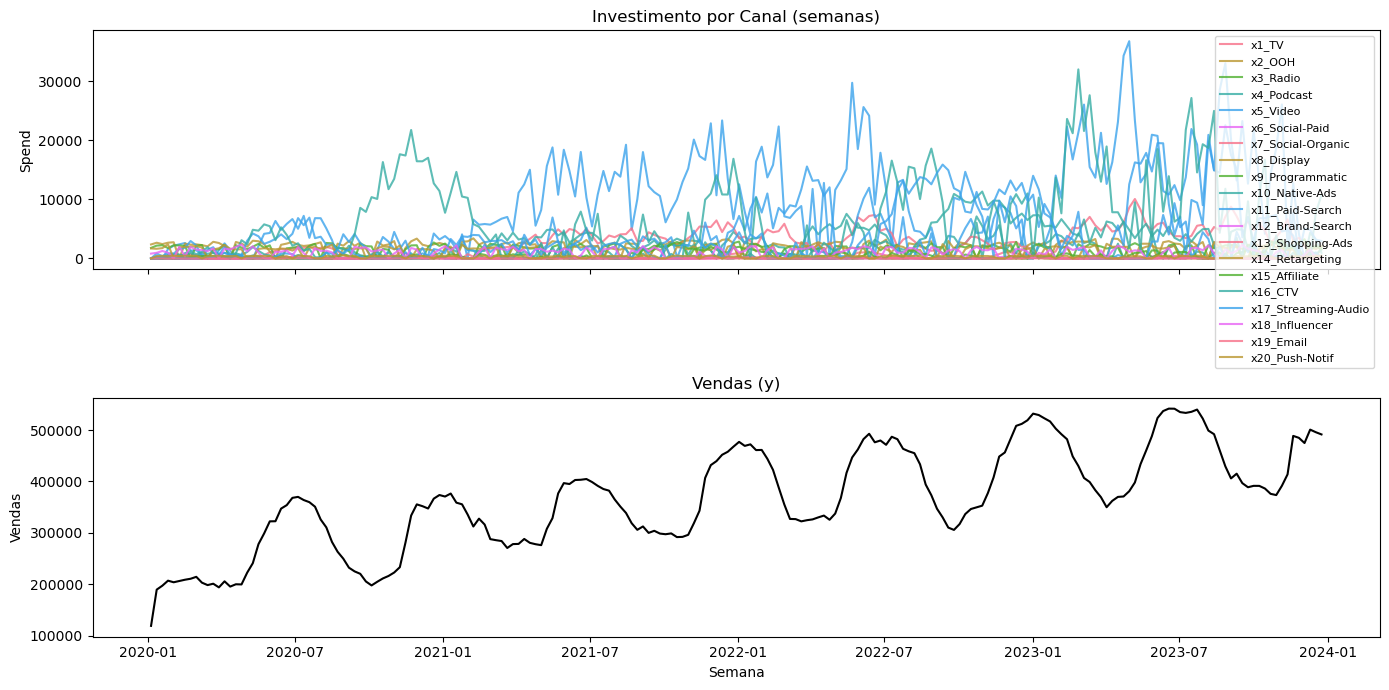

In [6]:
# Visualização dos gastos e vendas ao longo do tempo
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].set_title("Investimento por Canal (semanas)")
for ch in channel_columns:
    axes[0].plot(data_df["time"], data_df[ch], label=ch, alpha=0.8)
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_ylabel("Spend")

axes[1].set_title("Vendas (y)")
axes[1].plot(data_df["time"], data_df["y"], color="black", linewidth=1.5)
axes[1].set_ylabel("Vendas")
axes[1].set_xlabel("Semana")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dados_sinteticos.png"), dpi=150)
plt.show()

---
## Seção 2: Grafo Causal Verdadeiro (Ground Truth)

O gerador `mmm_param_recovery` cria cada canal com efeito **direto** em y via adstock + saturação (Hill function). Não há relações canal → canal no processo gerador. Portanto:

- Todos os `n_channels` canais são **diretos** (aresta canal_i → y)
- Nenhum canal mediado ou excluído no ground truth

Esta estrutura serve como referência para avaliar SHD, Precision, Recall e F1 do CD-NOTS.

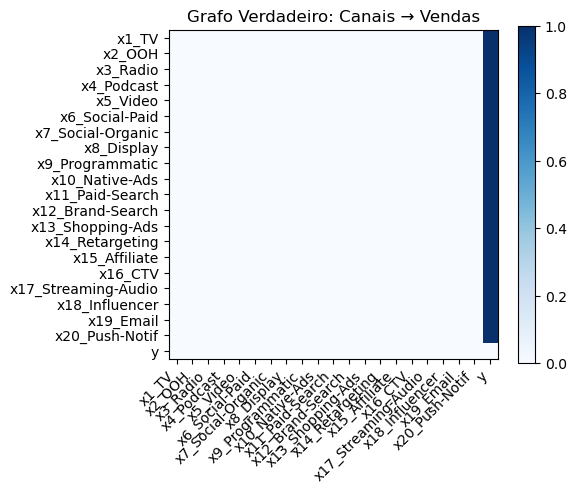

Arestas verdadeiras: 20 (todos os canais → y)

In [7]:
n_channels = len(channel_columns)
n_vars     = n_channels + 1   # canais + y
y_idx      = n_vars - 1

# Matriz de adjacência verdadeira: canal_i → y (índice n_vars-1)
true_adj = np.zeros((n_vars, n_vars))
for i in range(n_channels):
    true_adj[i, y_idx] = 1.0

var_labels = channel_columns + ["y"]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(true_adj, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_vars))
ax.set_xticklabels(var_labels, rotation=45, ha="right")
ax.set_yticklabels(var_labels)
ax.set_title("Grafo Verdadeiro: Canais → Vendas")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "grafo_verdadeiro.png"), dpi=150)
plt.show()

console.print(f"Arestas verdadeiras: {int(true_adj.sum())} (todos os canais → y)")

---
## Seção 3: Fase 0 — Descoberta Causal via CD-NOTS

**CD-NOTS** (Constraint-based Causal Discovery from Non-stationary Time Series):

1. Aumenta os dados com variáveis defasadas (t-1, t-2) e um nó temporal
2. Aplica o algoritmo PC com testes de independência condicional (Fisher-Z para N<200, KCI para N≥200)
3. Extrai arestas contemporâneas e defasadas
4. (Multi-geo) Constrói grafo de consenso via votação majoritária entre geos
5. Classifica canais como: **direto** → y, **mediado** (caminho indireto), **excluído** (sem caminho)

In [8]:
console.rule("[bold magenta]CD-NOTS: Descoberta Causal[/bold magenta]")

# ─── Preparar dados para CD-NOTS ─────────────────────────────────────────────
# discover_graph espera MultiIndex (date, geo) para processar cada geo
# separadamente e fazer consensus vote. Com índice inteiro (geo como coluna),
# todas as linhas seriam tratadas como uma série temporal contínua, quebrando
# a estrutura temporal nas fronteiras entre geos.
_n_geos = data_df["geo"].nunique() if "geo" in data_df.columns else 1

if _n_geos > 1:
    cdnots_data = (
        data_df.set_index(["time", "geo"])
        .sort_index()
        .rename_axis(index=["date", "geo"])
    )
    console.print(f"  Multi-geo ({_n_geos} geos): usando path per-geo + consensus vote")
else:
    cdnots_data = data_df
    console.print("  Single-geo: usando path national")

# ─── Descoberta causal ────────────────────────────────────────────────────────
causal_graph = cdnots_discovery.discover_graph(
    cdnots_data,
    channel_columns,
    alpha=0.05,
    max_lag=2,
    console=console,
)

# Salvar para reprodutibilidade
graph_path = os.path.join(RESULTS_DIR, "cdnots_graph.pkl")
with open(graph_path, "wb") as f:
    pickle.dump(causal_graph, f)
console.print(f"\n[green]Grafo salvo em:[/green] {graph_path}")


─────────────────────────────────────────── CD-NOTS: Descoberta Causal ────────────────────────────────────────────

Single-geo: usando path national

CD-NOTS Discovery: 21 vars, 1 geos, 208 timepoints, CI test: rcot, alpha: 0.05

       CD-NOTS Discovery Results        
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━┓
┃ Channel             ┃ → y ┃ Category ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━┩
│ x1_TV               │ ✓   │ direct   │
│ x2_OOH              │ ✓   │ direct   │
│ x3_Radio            │ ✗   │ mediated │
│ x4_Podcast          │ ✗   │ mediated │
│ x5_Video            │ ✓   │ direct   │
│ x6_Social-Paid      │ ✓   │ direct   │
│ x7_Social-Organic   │ ✓   │ direct   │
│ x8_Display          │ ✗   │ excluded │
│ x9_Programmatic     │ ✗   │ excluded │
│ x10_Native-Ads      │ ✗   │ mediated │
│ x11_Paid-Search     │ ✗   │ mediated │
│ x12_Brand-Search    │ ✓   │ direct   │
│ x13_Shopping-Ads    │ ✗   │ mediated │
│ x14_Retargeting     │ ✗   │ excluded │
│ x15_Affiliate       │ ✓   │ direct   │
│ x16_CTV             │ ✗   │ excluded │
│ x17_Streaming-Audio │ ✗   │ mediated │
│ x18_Influencer      │ ✗   │ mediated │
│ x19_Email           │ ✗   │ mediated │
│ x20_Push-Notif      │ ✓   │ direct   │
└─────────────────────┴─────┴──────────┘

Edges: 57 | Direct: ['x1_TV', 'x2_OOH', 'x5_Video', 'x6_Social-Paid', 'x7_Social-Organic', 'x12_Brand-Search', 
'x15_Affiliate', 'x20_Push-Notif'] | Excluded: ['x8_Display', 'x9_Programmatic', 'x14_Retargeting', 'x16_CTV'] | 
Runtime: 2.4s

Grafo salvo em: /home/ennes/mestrado/causalmmm_with_cdnots/notebooks/resultados/causal_large/cdnots_graph.pkl

  CD-NOTS vs. Grafo   
Verdadeiro — Métricas 
     Estruturais      
┏━━━━━━━━━━━┳━━━━━━━━┓
┃ Métrica   ┃ Valor  ┃
┡━━━━━━━━━━━╇━━━━━━━━┩
│ precision │ 0.1404 │
│ recall    │ 0.4    │
│ f1        │ 0.2078 │
│ fdr       │ 0.8596 │
│ shd       │ 61     │
│ tp        │ 8      │
│ fp        │ 49     │
│ fn        │ 12     │
│ tn        │ 351    │
└───────────┴────────┘

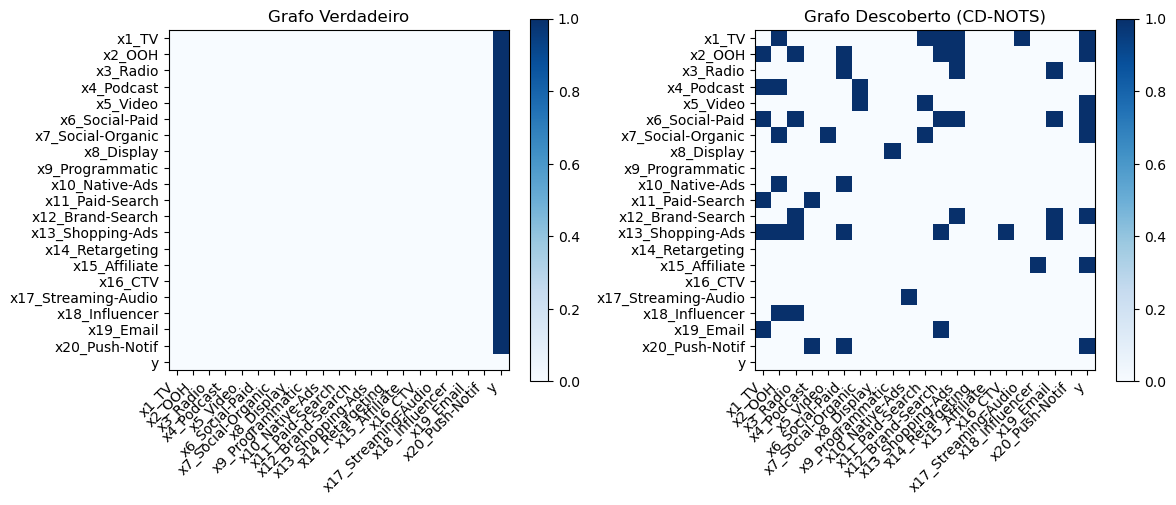

Canais diretos:   ['x1_TV', 'x2_OOH', 'x5_Video', 'x6_Social-Paid', 'x7_Social-Organic', 'x12_Brand-Search', 
'x15_Affiliate', 'x20_Push-Notif']

Canais mediados:  ['x3_Radio', 'x4_Podcast', 'x10_Native-Ads', 'x11_Paid-Search', 'x13_Shopping-Ads', 
'x17_Streaming-Audio', 'x18_Influencer', 'x19_Email']

Canais excluídos: ['x8_Display', 'x9_Programmatic', 'x14_Retargeting', 'x16_CTV']

Runtime CD-NOTS:  2.4s

In [9]:
# ─── Avaliação estrutural: descoberto vs. verdadeiro ─────────────────────────
struct_metrics = evaluate_causal_structure(
    learned_graph=causal_graph.adjacency_matrix,
    true_graph=true_adj,
)

table = Table(title="CD-NOTS vs. Grafo Verdadeiro — Métricas Estruturais")
table.add_column("Métrica", style="cyan")
table.add_column("Valor", style="green")
for k, v in struct_metrics.items():
    table.add_row(k, str(round(v, 4) if isinstance(v, float) else v))
console.print(table)

# Salvar métricas estruturais
pd.DataFrame([struct_metrics]).to_csv(
    os.path.join(RESULTS_DIR, "metricas_estruturais_cdnots.csv"), index=False
)

# ─── Visualização: heatmaps lado a lado ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, adj, title in zip(
    axes,
    [true_adj, causal_graph.adjacency_matrix],
    ["Grafo Verdadeiro", "Grafo Descoberto (CD-NOTS)"],
):
    im = ax.imshow(adj, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(n_vars))
    ax.set_yticks(range(n_vars))
    ax.set_xticklabels(var_labels, rotation=45, ha="right")
    ax.set_yticklabels(var_labels)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "grafos_comparacao.png"), dpi=150)
plt.show()

console.print(f"Canais diretos:   {list(causal_graph.direct_channels)}")
console.print(f"Canais mediados:  {list(causal_graph.mediated_channels)}")
console.print(f"Canais excluídos: {list(causal_graph.excluded_channels)}")
console.print(f"Runtime CD-NOTS:  {causal_graph.runtime_seconds:.1f}s")

---
## Seção 4: Configuração do Experimento MCMC

Hiperparâmetros reduzidos para execução interativa no notebook.
Para o benchmark completo, usar: `N_CHAINS=4, N_DRAWS=1000, N_TUNE=1000`.

In [10]:
# ─── Hiperparâmetros MCMC ─────────────────────────────────────────────────────
N_CHAINS      = 2
N_DRAWS       = 500
N_TUNE        = 500
TARGET_ACCEPT = 0.9
SAMPLER       = "nutpie"   # alternativas: "pymc", "blackjax", "numpyro"

# Dicionário central de resultados: {arm_name: (model, runtime_s, ess_dict) | None}
results: dict = {}

# ─── Especificação do experimento ────────────────────────────────────────────
import json as _json
_n_geos  = data_df["geo"].nunique() if "geo" in data_df.columns else 1
_n_weeks = data_df["time"].nunique() if "time" in data_df.columns else len(data_df)

experiment_spec = {
    "preset":    PRESET_NAME,
    "seed":      SEED,
    "n_geos":    int(_n_geos),
    "n_weeks":   int(_n_weeks),
    "channels":  channel_columns,
    "controls":  control_columns,
    "mcmc": {
        "n_chains":      N_CHAINS,
        "n_draws":       N_DRAWS,
        "n_tune":        N_TUNE,
        "target_accept": TARGET_ACCEPT,
        "sampler":       SAMPLER,
    },
}
with open(os.path.join(RESULTS_DIR, "experiment_spec.json"), "w") as _f:
    _json.dump(experiment_spec, _f, indent=2)
del _json, _n_geos, _n_weeks

console.print(f"Configuração: {N_CHAINS} chains × {N_DRAWS} draws, tune={N_TUNE}, sampler={SAMPLER}")
console.print(f"[green]Spec salva → {RESULTS_DIR}/experiment_spec.json[/green]")


Configuração: 2 chains × 500 draws, tune=500, sampler=nutpie

Spec salva → /home/ennes/mestrado/causalmmm_with_cdnots/notebooks/resultados/causal_large/experiment_spec.json

---
## Seção 5: Braço 1 — PyMC-Marketing Baseline

Priors padrão baseados em spend-share. Sem informação causal.

In [11]:
console.rule("[bold cyan]Braço 1: PyMC-Marketing Baseline[/bold cyan]")

pymc_baseline, rt_b1, ess_b1 = model_fitter.fit_pymc(
    data_df=data_df,
    channel_columns=channel_columns,
    control_columns=control_columns,
    sampler=SAMPLER,
    n_chains=N_CHAINS,
    n_draws=N_DRAWS,
    n_tune=N_TUNE,
    target_accept=TARGET_ACCEPT,
    seed=SEED,
    console=console,
)

results["Braço 1: PyMC Baseline"] = (pymc_baseline, rt_b1, ess_b1)
console.print(f"\n[green]✓[/green] Runtime: {rt_b1:.1f}s | ESS mín: {ess_b1.get('min', 'N/A'):.0f}")

──────────────────────────────────────── Braço 1: PyMC-Marketing Baseline ─────────────────────────────────────────

Fitting PyMC-Marketing with nutpie, 2 chains, 500 draws, 500 tune steps

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,6,0.05,511
,1000,3,0.05,255


Output()

Sampling: [y]


Output()

✓ PyMC-Marketing - nutpie: 1209.8s, ESS min: 29.556931674847895

✓ Runtime: 1209.8s | ESS mín: 30

---
## Seção 6: Braço 2 — Meridian Baseline

Priors padrão do Google Meridian. Sem informação causal. (Condicional à disponibilidade do pacote.)

In [12]:
if MERIDIAN_AVAILABLE:
    console.rule("[bold cyan]Braço 2: Meridian Baseline[/bold cyan]")

    meridian_baseline, rt_b2, ess_b2 = model_fitter.fit_meridian(
        data_df=data_df,
        channel_columns=channel_columns,
        control_columns=control_columns,
        n_chains=N_CHAINS,
        n_draws=N_DRAWS,
        n_tune=N_TUNE,
        target_accept=TARGET_ACCEPT,
        seed=SEED,
        console=console,
    )

    results["Braço 2: Meridian Baseline"] = (meridian_baseline, rt_b2, ess_b2)
    console.print(f"\n[green]✓[/green] Runtime: {rt_b2:.1f}s | ESS mín: {ess_b2.get('min', 'N/A'):.0f}")
else:
    console.print("[yellow]Braço 2 pulado: Meridian não disponível[/yellow]")
    results["Braço 2: Meridian Baseline"] = None

─────────────────────────────────────────── Braço 2: Meridian Baseline ────────────────────────────────────────────

Fitting Meridian with 2 chains, 500 draws, 500 tune steps

2026-04-05 10:37:12.927964: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


✓ Meridian: 407.8s, ESS min: 213.90184316336047

✓ Runtime: 407.8s | ESS mín: 214

---
## Seção 7: Braços 3 e 4 — Priors Calibrados pelo Grafo CD-NOTS

O grafo descoberto pelo CD-NOTS é traduzido em multiplicadores de prior:

| Categoria do Canal | Multiplicador σ | Adstock Beta(1, b) |
|--------------------|-----------------|--------------------|
| Direto (→ y)       | × 1.2           | b = 2 (decay moderado) |
| Mediado            | × 0.8           | b = 3 (decay padrão) |
| Excluído           | × 0.1           | b = 5 (decay rápido) |

Canais com evidência causal forte recebem priors mais largos (deixa os dados falar).
Canais sem caminho causal recebem regularização forte em direção a zero.

                          Ajuste de Priors via CD-NOTS                           
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Canal               ┃ Categoria ┃ σ base (médio) ┃ Multiplicador ┃ σ ajustado ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ x1_TV               │ direto    │ 0.0645         │ 1.5×          │ 0.0968     │
│ x2_OOH              │ direto    │ 0.0100         │ 1.5×          │ 0.0151     │
│ x3_Radio            │ mediado   │ 0.0141         │ 1.0×          │ 0.0141     │
│ x4_Podcast          │ mediado   │ 0.7892         │ 1.0×          │ 0.7892     │
│ x5_Video            │ direto    │ 5.0477         │ 1.5×          │ 7.5542     │
│ x6_Social-Paid      │ direto    │ 0.0246         │ 1.5×          │ 0.0369     │
│ x7_Social-Organic   │ direto    │ 1.5384         │ 1.5×          │ 2.3017     │
│ x8_Display          │ excluído  │ 1.0576         │ 1.0×          │ 1.0576     │
│ x9_Programmatic     │ excluído  │ 0.8367         │ 1.0×          │ 0.8367     │
│ x10_Native-Ads      │ mediado   │ 1.3453         │ 1.0×          │ 1.3453     │
│ x11_Paid-Search     │ mediado   │ 2.3757         │ 1.0×          │ 2.3757     │
│ x12_Brand-Search    │ direto    │ 0.0152         │ 1.5×          │ 0.0225     │
│ x13_Shopping-Ads    │ mediado   │ 0.0360         │ 1.0×          │ 0.0360     │
│ x14_Retargeting     │ excluído  │ 0.7484         │ 1.0×          │ 0.7484     │
│ x15_Affiliate       │ direto    │ 0.3188         │ 1.5×          │ 0.4759     │
│ x16_CTV             │ excluído  │ 3.4039         │ 1.0×          │ 3.4039     │
│ x17_Streaming-Audio │ mediado   │ 1.6499         │ 1.0×          │ 1.6499     │
│ x18_Influencer      │ mediado   │ 0.5638         │ 1.0×          │ 0.5638     │
│ x19_Email           │ mediado   │ 0.0019         │ 1.0×          │ 0.0019     │
│ x20_Push-Notif      │ direto    │ 0.1584         │ 1.5×          │ 0.2375     │
└─────────────────────┴───────────┴────────────────┴───────────────┴────────────┘

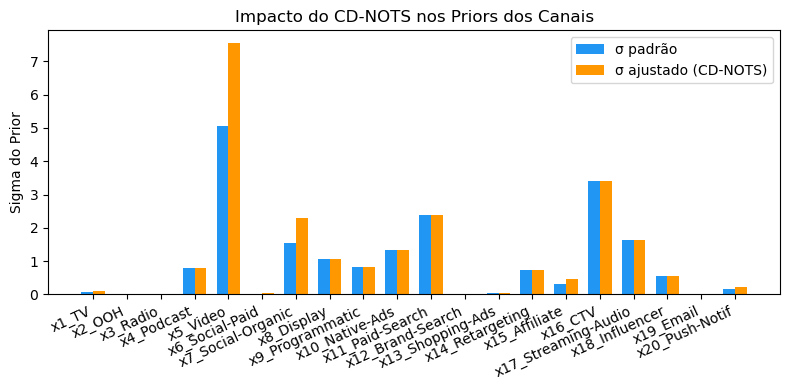

In [13]:
# ─── Visualização do impacto do grafo nos priors ──────────────────────────────
prior_sigma  = model_builder.calculate_prior_sigma(data_df, channel_columns)
multipliers  = cdnots_model_builder._compute_sigma_multipliers(channel_columns, causal_graph)
adj_sigma    = prior_sigma * multipliers[np.newaxis, :]

table = Table(title="Ajuste de Priors via CD-NOTS")
table.add_column("Canal",           style="cyan")
table.add_column("Categoria",       style="magenta")
table.add_column("σ base (médio)",  style="yellow")
table.add_column("Multiplicador",   style="green")
table.add_column("σ ajustado",      style="white")

for i, ch in enumerate(channel_columns):
    cat = (
        "direto"   if ch in causal_graph.direct_channels
        else "mediado"  if ch in causal_graph.mediated_channels
        else "excluído"
    )
    table.add_row(
        ch, cat,
        f"{prior_sigma.mean(axis=0)[i]:.4f}",
        f"{multipliers[i]:.1f}×",
        f"{adj_sigma.mean(axis=0)[i]:.4f}",
    )
console.print(table)

# Gráfico de barras: sigma antes e depois
x = np.arange(n_channels)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, prior_sigma.mean(axis=0), width, label="σ padrão", color="#2196F3")
ax.bar(x + width/2, adj_sigma.mean(axis=0),   width, label="σ ajustado (CD-NOTS)", color="#FF9800")
ax.set_xticks(x)
ax.set_xticklabels(channel_columns, rotation=25, ha="right")
ax.set_title("Impacto do CD-NOTS nos Priors dos Canais")
ax.set_ylabel("Sigma do Prior")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "ajuste_priors.png"), dpi=150)
plt.show()

In [14]:
console.rule("[bold cyan]Braço 3: PyMC-Marketing + CD-NOTS[/bold cyan]")

pymc_cdnots, rt_b3, ess_b3 = cdnots_fitter.fit_pymc_with_graph(
    data_df=data_df,
    channel_columns=channel_columns,
    control_columns=control_columns,
    graph=causal_graph,
    sampler=SAMPLER,
    n_chains=N_CHAINS,
    n_draws=N_DRAWS,
    n_tune=N_TUNE,
    target_accept=TARGET_ACCEPT,
    seed=SEED,
    console=console,
)

results["Braço 3: PyMC + CD-NOTS"] = (pymc_cdnots, rt_b3, ess_b3)
console.print(f"\n[green]✓[/green] Runtime: {rt_b3:.1f}s | ESS mín: {ess_b3.get('min', 'N/A'):.0f}")

──────────────────────────────────────── Braço 3: PyMC-Marketing + CD-NOTS ────────────────────────────────────────

Fitting PyMC-Marketing + CD-NOTS with nutpie, 2 chains, 500 draws, 500 tune steps

Graph: 8 direct, 8 mediated, 4 excluded


  Prior adjustments (damping=0.5, floor=0.4):
                             x1_TV: σ×1.500 ↑  (p=0.0001, direct)
                            x2_OOH: σ×1.500 ↑  (p=0.0000, direct)
                          x3_Radio: σ×1.000 =  (p=1.0000, mediated)
                        x4_Podcast: σ×1.000 =  (p=1.0000, mediated)
                          x5_Video: σ×1.497 ↑  (p=0.0068, direct)
                    x6_Social-Paid: σ×1.500 ↑  (p=0.0000, direct)
                 x7_Social-Organic: σ×1.496 ↑  (p=0.0077, direct)
                        x8_Display: σ×1.000 =  (p=1.0000, excluded)
                   x9_Programmatic: σ×1.000 =  (p=1.0000, excluded)
                    x10_Native-Ads: σ×1.000 =  (p=1.0000, mediated)
                   x11_Paid-Search: σ×1.000 =  (p=1.0000, mediated)
                  x12_Brand-Search: σ×1.477 ↑  (p=0.0464, direct)
                  x13_Shopping-Ads: σ×1.000 =  (p=1.0000, mediated)
                   x14_Retargeting: σ×1.000 =  (p=1.0000, excluded)
             

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,3,0.05,255
,1000,3,0.04,511


Output()

Sampling: [y]


Output()

✓ PyMC + CD-NOTS - nutpie: 1137.3s, ESS min: 49.546099182862214

✓ Runtime: 1137.3s | ESS mín: 50

In [15]:
if MERIDIAN_AVAILABLE:
    console.rule("[bold cyan]Braço 4: Meridian + CD-NOTS[/bold cyan]")

    meridian_cdnots, rt_b4, ess_b4 = cdnots_fitter.fit_meridian_with_graph(
        data_df=data_df,
        channel_columns=channel_columns,
        control_columns=control_columns,
        graph=causal_graph,
        n_chains=N_CHAINS,
        n_draws=N_DRAWS,
        n_tune=N_TUNE,
        target_accept=TARGET_ACCEPT,
        seed=SEED,
        console=console,
    )

    results["Braço 4: Meridian + CD-NOTS"] = (meridian_cdnots, rt_b4, ess_b4)
    console.print(f"\n[green]✓[/green] Runtime: {rt_b4:.1f}s | ESS mín: {ess_b4.get('min', 'N/A'):.0f}")
else:
    console.print("[yellow]Braço 4 pulado: Meridian não disponível[/yellow]")
    results["Braço 4: Meridian + CD-NOTS"] = None

─────────────────────────────────────────── Braço 4: Meridian + CD-NOTS ───────────────────────────────────────────

Fitting Meridian + CD-NOTS with 2 chains, 500 draws, 500 tune steps

Graph: 8 direct, 8 mediated, 4 excluded


  Prior adjustments (damping=0.5, floor=0.4):
                             x1_TV: σ×1.500 ↑  (p=0.0001, direct)
                            x2_OOH: σ×1.500 ↑  (p=0.0000, direct)
                          x3_Radio: σ×1.000 =  (p=1.0000, mediated)
                        x4_Podcast: σ×1.000 =  (p=1.0000, mediated)
                          x5_Video: σ×1.497 ↑  (p=0.0068, direct)
                    x6_Social-Paid: σ×1.500 ↑  (p=0.0000, direct)
                 x7_Social-Organic: σ×1.496 ↑  (p=0.0077, direct)
                        x8_Display: σ×1.000 =  (p=1.0000, excluded)
                   x9_Programmatic: σ×1.000 =  (p=1.0000, excluded)
                    x10_Native-Ads: σ×1.000 =  (p=1.0000, mediated)
                   x11_Paid-Search: σ×1.000 =  (p=1.0000, mediated)
                  x12_Brand-Search: σ×1.477 ↑  (p=0.0464, direct)
                  x13_Shopping-Ads: σ×1.000 =  (p=1.0000, mediated)
                   x14_Retargeting: σ×1.000 =  (p=1.0000, excluded)
             

✓ Meridian + CD-NOTS: 399.7s, ESS min: 151.65878337809096

✓ Runtime: 399.7s | ESS mín: 152

---
## Seção 8: Avaliação Comparativa — Métricas de Ajuste

**Métricas preditivas** por braço:
- R² (coeficiente de determinação)
- MAPE % (Mean Absolute Percentage Error)
- sRMSE (scaled Root Mean Squared Error)
- Bias
- Durbin-Watson (autocorrelação dos resíduos)

In [16]:
all_perf_rows = []

for arm_name, arm_result in results.items():
    if arm_result is None:
        continue
    model_obj, runtime, ess = arm_result

    if "PyMC" in arm_name:
        rows = evaluation.evaluate_pymc_fit(model_obj, data_df, SAMPLER)
    elif "Meridian" in arm_name:
        rows = evaluation.evaluate_meridian_fit(model_obj, data_df)
    else:
        continue

    for r in rows:
        r["Braço"] = arm_name
    all_perf_rows.extend(rows)

perf_df = pd.DataFrame(all_perf_rows)
perf_df.to_csv(os.path.join(RESULTS_DIR, "metricas_ajuste.csv"), index=False)
console.print("[green]Métricas de ajuste salvas.[/green]")
perf_df

Métricas de ajuste salvas.

,Model,Geo,R²,MAPE (%),Bias,SRMSE,Durbin-Watson,Braço
0,PyMC-Marketing - nutpie,national,0.9749,3.43,-50.050800,0.0415,0.696,Braço 1: PyMC Baseline
1,Meridian,geo_a,0.9911,2.03,5.266200,0.0247,1.095,Braço 2: Meridian Baseline
2,PyMC-Marketing - nutpie,national,0.9765,3.40,7.450500,0.0402,0.703,Braço 3: PyMC + CD-NOTS
3,Meridian,geo_a,0.9920,1.93,21.512199,0.0235,1.142,Braço 4: Meridian + CD-NOTS


---
## Seção 9: Avaliação Comparativa — Contribuição dos Canais

**Métricas de atribuição** (ground truth recovery):
- sRMSE e MAPE das contribuições estimadas vs. verdadeiras por canal
- Correlação entre contribuições estimadas e verdadeiras
- Recovery do ROAS por canal

In [17]:
all_contrib_rows    = []
all_contrib_summary = []

for arm_name, arm_result in results.items():
    if arm_result is None:
        continue
    model_obj, runtime, ess = arm_result

    try:
        if "PyMC" in arm_name:
            ch_df, avg_metrics = evaluation.evaluate_pymc_channel_contributions(
                model_obj, truth_df, channel_columns, SAMPLER, PRESET_NAME
            )
        elif "Meridian" in arm_name:
            ch_df, avg_metrics = evaluation.evaluate_meridian_channel_contributions(
                model_obj, truth_df, channel_columns, PRESET_NAME
            )
        else:
            continue

        ch_df["Braço"] = arm_name
        all_contrib_rows.append(ch_df)
        all_contrib_summary.append({"Braço": arm_name, **avg_metrics})

    except Exception as e:
        console.print(f"[red]Erro ao avaliar contribuições de {arm_name}: {e}[/red]")

if all_contrib_rows:
    contrib_df = pd.concat(all_contrib_rows, ignore_index=True)
    contrib_df.to_csv(os.path.join(RESULTS_DIR, "contribuicao_canais.csv"), index=False)

contrib_summary_df = pd.DataFrame(all_contrib_summary)
contrib_summary_df.to_csv(os.path.join(RESULTS_DIR, "contribuicao_canais_resumo.csv"), index=False)
console.print("[green]Métricas de contribuição salvas.[/green]")
contrib_summary_df

Métricas de contribuição salvas.

,Braço,Bias,SRMSE,R²,MAPE (%)
0,Braço 1: PyMC Baseline,-751.530011,1.674861,-34.322689,304.488684
1,Braço 2: Meridian Baseline,NaN,NaN,NaN,NaN
2,Braço 3: PyMC + CD-NOTS,-632.334333,1.706691,-34.654494,360.948903
3,Braço 4: Meridian + CD-NOTS,NaN,NaN,NaN,NaN


---
## Seção 10: Diagnósticos de Convergência MCMC

- **ESS** (Effective Sample Size): mínimo e mediana
- **R-hat**: máximo e contagem de variáveis com R-hat > 1.1
- **Divergências**: contagem total

In [18]:
diag_rows = []

for arm_name, arm_result in results.items():
    if arm_result is None:
        diag_rows.append({"Braço": arm_name, "Status": "N/D"})
        continue
    model_obj, runtime, ess = arm_result

    # Obter inference data
    idata = getattr(model_obj, "idata", None) or getattr(model_obj, "inference_data", None)

    if idata is not None:
        try:
            divergencias = diagnostics.compute_divergences(idata)
            rhat         = diagnostics.compute_rhat(idata)
        except Exception:
            divergencias = None
            rhat = {"max": None, "bad_count": None}
    else:
        divergencias = None
        rhat = {"max": None, "bad_count": None}

    diag_rows.append({
        "Braço":        arm_name,
        "ESS mín":      round(ess.get("min",  np.nan), 0) if ess else None,
        "ESS q50":      round(ess.get("q50",  np.nan), 0) if ess else None,
        "R-hat máx":    round(rhat["max"],       4) if rhat["max"]       is not None else None,
        "R-hat > 1.1":  rhat["bad_count"]                if rhat["bad_count"]  is not None else None,
        "Divergências": divergencias,
        "Runtime (s)":  round(runtime, 1),
    })

diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(os.path.join(RESULTS_DIR, "diagnosticos_mcmc.csv"), index=False)
console.print("[green]Diagnósticos salvos.[/green]")
diag_df

Diagnósticos salvos.

,Braço,ESS mín,ESS q50,R-hat máx,R-hat > 1.1,Divergências,Runtime (s)
0,Braço 1: PyMC Baseline,30.0,359.0,1.10,0,9,1209.8
1,Braço 2: Meridian Baseline,214.0,229.0,1.01,0,0,407.8
2,Braço 3: PyMC + CD-NOTS,50.0,478.0,1.05,0,6,1137.3
3,Braço 4: Meridian + CD-NOTS,152.0,166.0,1.01,0,1,399.7


---
## Seção 11: Tabela Resumo Final

Consolida todas as dimensões de avaliação em uma única tabela comparativa.

In [19]:
summary_rows = []

for arm_name, arm_result in results.items():
    if arm_result is None:
        summary_rows.append({"Braço": arm_name, "Status": "N/D"})
        continue
    model_obj, runtime, ess = arm_result

    # Métricas de ajuste (média entre geos)
    try:
        if "PyMC" in arm_name:
            fit_rows = evaluation.evaluate_pymc_fit(model_obj, data_df, SAMPLER)
        else:
            fit_rows = evaluation.evaluate_meridian_fit(model_obj, data_df)
        r2_mean   = np.nanmean([r["R²"]      for r in fit_rows if r.get("R²")      is not None])
        mape_mean = np.nanmean([r["MAPE (%)"] for r in fit_rows if r.get("MAPE (%)") is not None])
    except Exception:
        r2_mean = mape_mean = np.nan

    # Métricas de contribuição
    contrib_row = next((r for r in all_contrib_summary if r["Braço"] == arm_name), {})

    # Métricas estruturais (só para braços CD-NOTS)
    shd = struct_metrics.get("shd", None) if "CD-NOTS" in arm_name else None
    f1  = struct_metrics.get("f1",  None) if "CD-NOTS" in arm_name else None

    summary_rows.append({
        "Braço":             arm_name,
        "R² (fit)": round(r2_mean,  4) if not np.isnan(r2_mean)  else None,
        "MAPE % (fit)": round(mape_mean, 2) if not np.isnan(mape_mean) else None,
        "sRMSE (contrib)": round(contrib_row.get("SRMSE", np.nan), 4) if contrib_row else None,
        "MAPE % (contrib)": round(contrib_row.get("MAPE (%)", np.nan), 2) if contrib_row else None,
        "ESS mín":    round(ess.get("min", np.nan), 0) if ess else None,
        "ESS q50":    round(ess.get("q50", np.nan), 0) if ess else None,
        "SHD grafo":  shd,
        "F1 grafo":   round(f1, 4) if f1 is not None else None,
        "Runtime (s)": round(runtime, 1),
        "CD-NOTS":    "Sim" if "CD-NOTS" in arm_name else "Não",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(RESULTS_DIR, "resumo_experimento.csv"), index=False)
console.print("[bold green]Resumo do experimento salvo.[/bold green]")
summary_df

Resumo do experimento salvo.

,Braço,R² (fit),MAPE % (fit),sRMSE (contrib),MAPE % (contrib),ESS mín,ESS q50,SHD grafo,F1 grafo,Runtime (s),CD-NOTS
0,Braço 1: PyMC Baseline,0.9749,3.43,1.6749,304.49,30.0,359.0,NaN,NaN,1209.8,Não
1,Braço 2: Meridian Baseline,0.9911,2.03,NaN,NaN,214.0,229.0,NaN,NaN,407.8,Não
2,Braço 3: PyMC + CD-NOTS,0.9765,3.40,1.7067,360.95,50.0,478.0,61.0,0.2078,1137.3,Sim
3,Braço 4: Meridian + CD-NOTS,0.9920,1.93,NaN,NaN,152.0,166.0,61.0,0.2078,399.7,Sim


---
## Seção 12: Visualizações Comparativas

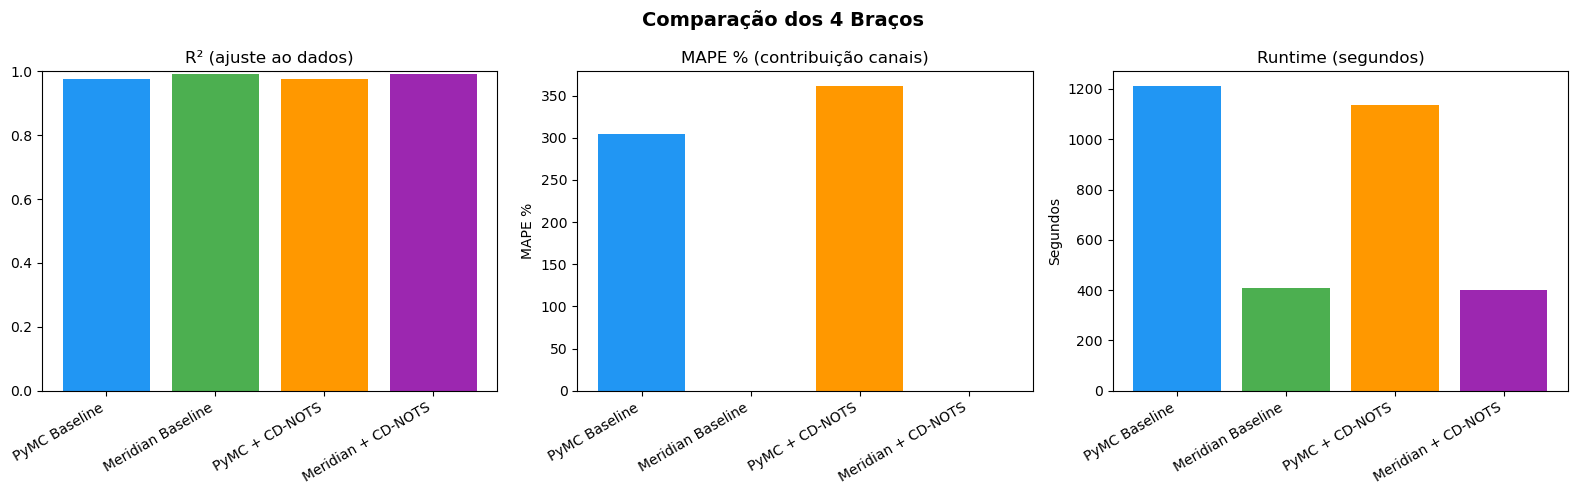

In [20]:
# Filtra apenas braços com resultados
if "Status" in summary_df.columns:
    valid_df = summary_df[summary_df["Status"] != "N/D"].copy()
else:
    valid_df = summary_df.copy()
valid_df = valid_df.dropna(subset=["R² (fit)"])

if len(valid_df) == 0:
    console.print("[yellow]Sem resultados válidos para visualização.[/yellow]")
else:
    modelos = valid_df["Braço"].str.split(": ").str[1].tolist()
    cores   = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"][: len(modelos)]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Comparação dos 4 Braços", fontsize=14, fontweight="bold")

    # R² de ajuste
    axes[0].bar(range(len(modelos)), valid_df["R² (fit)"].fillna(0), color=cores)
    axes[0].set_xticks(range(len(modelos)))
    axes[0].set_xticklabels(modelos, rotation=30, ha="right")
    axes[0].set_title("R² (ajuste ao dados)")
    axes[0].set_ylim(0, 1)
    axes[0].axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)

    # MAPE de contribuição
    if "MAPE % (contrib)" in valid_df.columns and valid_df["MAPE % (contrib)"].notna().any():
        axes[1].bar(range(len(modelos)), valid_df["MAPE % (contrib)"].fillna(0), color=cores)
        axes[1].set_xticks(range(len(modelos)))
        axes[1].set_xticklabels(modelos, rotation=30, ha="right")
        axes[1].set_title("MAPE % (contribuição canais)")
        axes[1].set_ylabel("MAPE %")
    else:
        axes[1].text(0.5, 0.5, "N/D", ha="center", va="center", transform=axes[1].transAxes)
        axes[1].set_title("MAPE % (contribuição canais)")

    # Runtime
    axes[2].bar(range(len(modelos)), valid_df["Runtime (s)"].fillna(0), color=cores)
    axes[2].set_xticks(range(len(modelos)))
    axes[2].set_xticklabels(modelos, rotation=30, ha="right")
    axes[2].set_title("Runtime (segundos)")
    axes[2].set_ylabel("Segundos")

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "comparacao_4bracos.png"), dpi=150)
    plt.show()

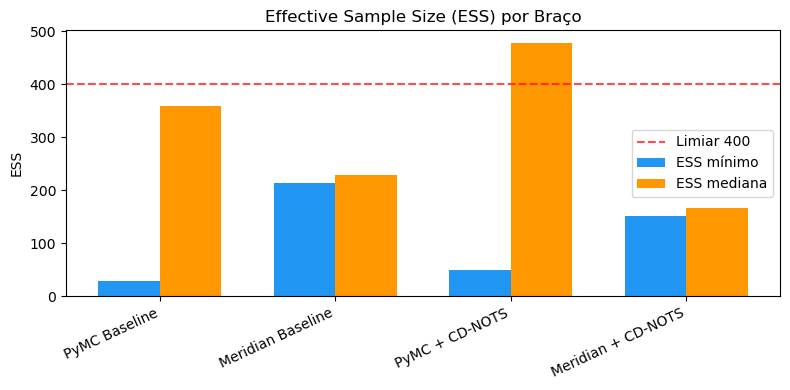

In [21]:
# ESS Comparison
if len(valid_df) > 0 and "ESS mín" in valid_df.columns and valid_df["ESS mín"].notna().any():
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(modelos))
    width = 0.35
    ess_min = valid_df["ESS mín"].fillna(0).values
    ess_q50 = valid_df["ESS q50"].fillna(0).values
    ax.bar(x - width/2, ess_min, width, label="ESS mínimo",  color="#2196F3")
    ax.bar(x + width/2, ess_q50, width, label="ESS mediana", color="#FF9800")
    ax.axhline(y=400, color="red", linestyle="--", alpha=0.7, label="Limiar 400")
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, rotation=25, ha="right")
    ax.set_title("Effective Sample Size (ESS) por Braço")
    ax.set_ylabel("ESS")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "ess_comparacao.png"), dpi=150)
    plt.show()

# ---
## Seção 13: Limpeza de Memória

In [22]:
for key in list(results.keys()):
    arm_result = results.pop(key)
    if arm_result is not None:
        model_obj, _, _ = arm_result
        del model_obj
        del arm_result

gc.collect()
console.print("[green]Memória liberada.[/green]")

Memória liberada.

---
## Seção 14: Conclusões

### Arquivos gerados

Todos os resultados foram salvos em `notebooks/resultados/`:

| Arquivo | Conteúdo |
|---------|----------|
| `resumo_experimento.csv` | Todas as métricas por braço |
| `metricas_ajuste.csv` | R², MAPE, sRMSE, Bias, DW por geo |
| `contribuicao_canais.csv` | Métricas de atribuição por canal×geo |
| `contribuicao_canais_resumo.csv` | Médias de atribuição por braço |
| `diagnosticos_mcmc.csv` | ESS, R-hat, divergências |
| `metricas_estruturais_cdnots.csv` | SHD, F1, Precision, Recall do grafo |
| `cdnots_graph.pkl` | Objeto CausalGraph para reprodutibilidade |
| `comparacao_4bracos.png` | Gráfico comparativo principal |
| `grafos_comparacao.png` | Heatmaps dos grafos verdadeiro vs. descoberto |
| `ajuste_priors.png` | Impacto do CD-NOTS nos priors |

---

### Análise dos Resultados

> **[PLACEHOLDER]** — Preencher após execução com os resultados reais.

**Descoberta Causal (Seção 3):**
- SHD: `___` | Precision: `___` | Recall: `___` | F1: `___`
- Canais diretos identificados: `___`
- Canais excluídos: `___`

**Ajuste ao dados (R²):**
- Braço 1 (PyMC baseline): `___`
- Braço 2 (Meridian baseline): `___`
- Braço 3 (PyMC + CD-NOTS): `___`
- Braço 4 (Meridian + CD-NOTS): `___`

**Atribuição de canais (MAPE %):**
- Braço 1 vs Braço 3 (PyMC): `___` vs `___` → melhoria de `___%`
- Braço 2 vs Braço 4 (Meridian): `___` vs `___` → melhoria de `___%`

**Convergência MCMC:**
- ESS mínimo satisfatório (> 400) em todos os braços: `[Sim/Não]`
- R-hat < 1.1 em todos os parâmetros: `[Sim/Não]`

---

### Hipóteses Testadas

1. **H1**: CD-NOTS consegue descobrir estruturas causais informativas com 104 observações semanais. → _[a ser validado pelo SHD/F1]_

2. **H2**: A tradução do grafo em priors ajustados melhora a acurácia preditiva e de atribuição. → _[a ser validado comparando Braços 1vs3 e 2vs4]_

3. **H3**: A abordagem é aplicável em contextos com poucos dados geográficos (N < 10 geos). → _[validado pelo preset `small_business` com 1 geo]_